### 2D Polynomial Reproduction for SIAC

* Checks that the SIAC code correctly reproduces polynomials in 1D
* For this, the modal DG basis is created using an exact $L^2$-projection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [2]:
from src.mesh import build_uniform_mesh_2d
from src.grid import local_cell_center_nodes_1d, build_grid_from_local_nodes_2d
from src.siac_modal import apply_siac_modal_dg_2d, trim_valid_siac_region_2d
from src.projection_approach import l2_project_exact_func_to_dg_2d
from src.evaluation import eval_dg_on_local_nodes_2d


In [ ]:

# -----------------------------
# 0. Problem / domain setup
# -----------------------------
xmin, xmax = -1, 1
ymin, ymax = -1, 1
xlim = (xmin, xmax)
ylim = (ymin, ymax)

poly_deg = 5

# --------------------------------------------------
# 1. Exact polynomial test function
# --------------------------------------------------
def exact_poly2d_scaled(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    xhat = 2.0 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    yhat = 2.0 * (y - ylim[0]) / (ylim[1] - ylim[0]) - 1.0

    u = 1.0 - 0.8*xhat**2 - 0.6*yhat**2

    if poly_deg >= 3:
        u += 0.15*xhat**3 - 0.12*yhat**3 + 0.08*xhat*yhat
    if poly_deg >= 4:
        u += 0.5*xhat**4 + 0.4*yhat**4 - 0.25*xhat**2*yhat**2
    if poly_deg >= 5:
        u += -0.18*xhat**5 + 0.12*xhat**3*yhat**2
    if poly_deg >= 6:
        u += -0.1*xhat**6
    return u

# DG polynomial degree  (SIAC should reproduce p = (poly_deg - 1) / 2 exactly)
p = int(np.ceil((poly_deg-1) / 2))

# DG mesh resolution
Kx, Ky = 24, 24

# SIAC parameters
moments = 2 * p
BSorder = p + 1

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_2d(Kx=Kx, Ky=Ky, p=p, xlim=xlim, ylim=ylim)

# -----------------------------
# 3. Exact L2 projection of polynomial onto modal DG
# -----------------------------
dg = l2_project_exact_func_to_dg_2d(
    func=exact_poly2d_scaled, 
    mesh=mesh,
    poly_max_deg=poly_deg, 
    quad_order=int(np.ceil(poly_deg + p + 1) / 2), 
    add_noise=False
)

# -----------------------------
# 4. Fine local nodes per element
# -----------------------------
n_eval = 10 * int(np.ceil(poly_deg + p + 1) / 2)
nodes_fine = local_cell_center_nodes_1d(n_eval)

# -----------------------------
# 5. Build global fine grid
# -----------------------------
X_fine, Y_fine = build_grid_from_local_nodes_2d(
    dg["mesh"],
    nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
U_exact = exact_poly2d_scaled(
    x=X_fine,
    y=Y_fine,
)

U_dg = eval_dg_on_local_nodes_2d(
    dg,
    eval_nodes=nodes_fine
)

U_siac = apply_siac_modal_dg_2d(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region_2d(
    U_exact,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder, 
    return_trim=True
)

dg_trim = trim_valid_siac_region_2d(
    U_dg,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder
)

siac_trim = trim_valid_siac_region_2d(
    U_siac,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder
)

# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print(f"Exact Polynomial degree:    {poly_deg}")
print(f"DG degree:                  p = {p}")
print(f"SIAC parameters:            r = {moments}, n = {BSorder}")

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))


Exact Polynomial degree:    5
DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 160
DG max err   : 7.175241565215984e-05
DG rel err   : 1.3433217206442892e-05
SIAC max err : 3.774758283725532e-15
SIAC rel err : 9.221754901217318e-16


**Note**

For a polynomial of degree $p$
* DG should give machine precision if the DG degree is $p$ or higher
* SIAC should machine precision if the DG degree is $\left\lceil\tfrac{p-1}{2}\right\rceil$

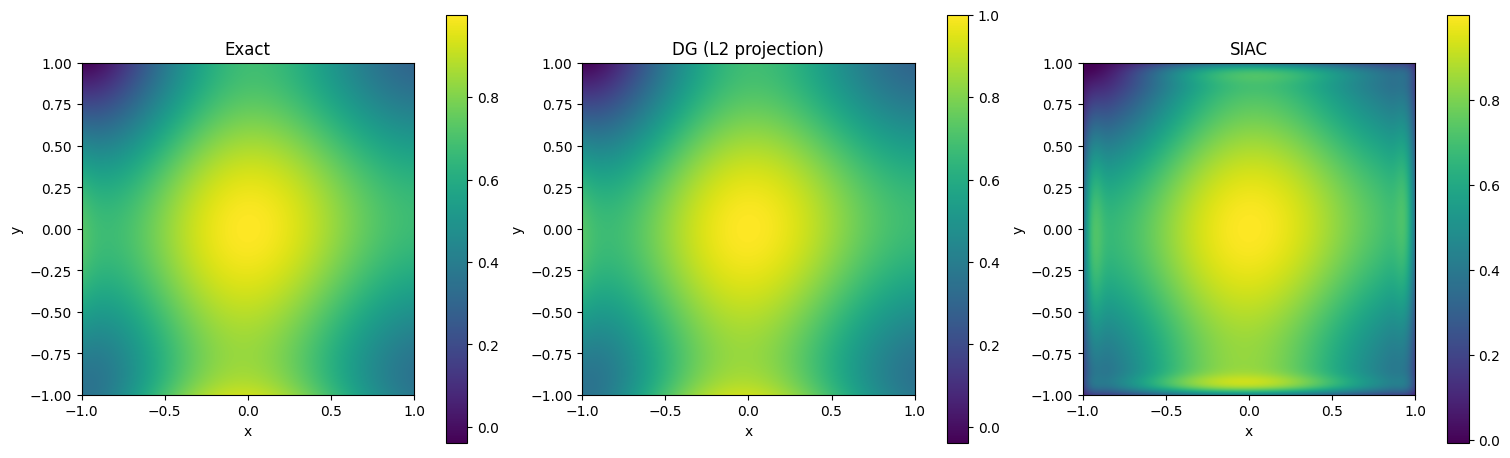

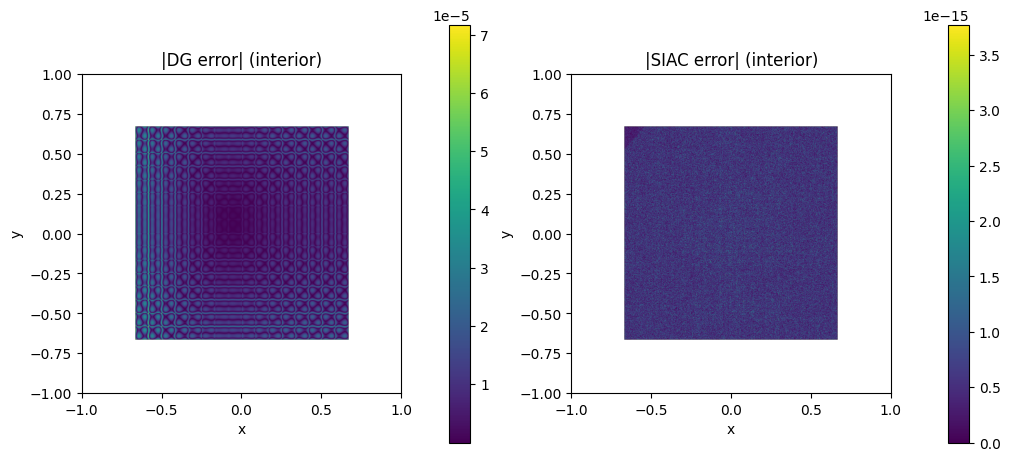

In [4]:

# --------------------------------------------------
# 7. Plots: exact, DG, SIAC
# --------------------------------------------------
# Visualize only the valid interior region while keeping full-size images:

dg_err_plot = np.full_like(U_exact, np.nan, dtype=float)
siac_err_plot = np.full_like(U_exact, np.nan, dtype=float)

sl = slice(trim, -trim)
dg_err_plot[sl, sl] = np.abs(err_dg)
siac_err_plot[sl, sl] = np.abs(err_siac)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axes[0].imshow(
    U_exact,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[0].set_title("Exact")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    U_dg,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[1].set_title("DG (L2 projection)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(
    U_siac,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[2].set_title("SIAC")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.show()

# --------------------------------------------------
# 8. Error plots
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

im3 = axes[0].imshow(
    np.abs(dg_err_plot),
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[0].set_title("|DG error| (interior)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im3, ax=axes[0])

im4 = axes[1].imshow(
    np.abs(siac_err_plot),
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[1].set_title("|SIAC error| (interior)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im4, ax=axes[1])

plt.show()


**Observe** the edge artifacts from the SIAC postprocessor (due to zero padding)

### Test with noise

In [5]:

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_2d(Kx=Kx, Ky=Ky, p=p, xlim=xlim, ylim=ylim)

# -----------------------------
# 3. Exact L2 projection of polynomial onto modal DG
# -----------------------------
dg = l2_project_exact_func_to_dg_2d(
    func=exact_poly2d_scaled, 
    mesh=mesh,
    poly_max_deg=poly_deg, 
    quad_order=int(np.ceil(poly_deg + p + 1) / 2), 
    add_noise=True
)

# -----------------------------
# 4. Fine local nodes per element
# -----------------------------
n_eval = 10 * int(np.ceil(poly_deg + p + 1) / 2)
nodes_fine = local_cell_center_nodes_1d(n_eval)

# -----------------------------
# 5. Build global fine grid
# -----------------------------
X_fine, Y_fine = build_grid_from_local_nodes_2d(
    dg["mesh"],
    nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
U_exact = exact_poly2d_scaled(
    x=X_fine,
    y=Y_fine,
)

U_dg = eval_dg_on_local_nodes_2d(
    dg,
    eval_nodes=nodes_fine
)

U_siac = apply_siac_modal_dg_2d(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region_2d(
    U_exact,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder, 
    return_trim=True
)

dg_trim = trim_valid_siac_region_2d(
    U_dg,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder
)

siac_trim = trim_valid_siac_region_2d(
    U_siac,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder
)

# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print(f"Exact Polynomial degree:    {poly_deg}")
print(f"DG degree:                  p = {p}")
print(f"SIAC parameters:            r = {moments}, n = {BSorder}")

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))


Exact Polynomial degree:    5
DG degree:                  p = 2
SIAC parameters:            r = 4, n = 3
trim = 160
DG max err   : 0.00761961307486958
DG rel err   : 0.0014032745153129025
SIAC max err : 0.0012973264615115943
SIAC rel err : 0.0004648563898684664


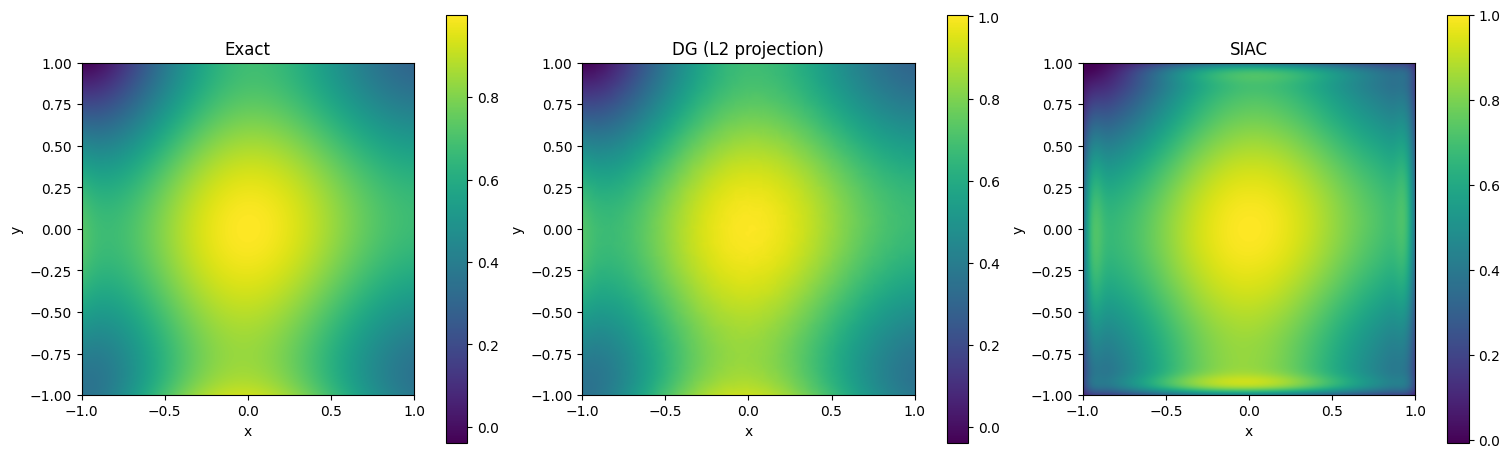

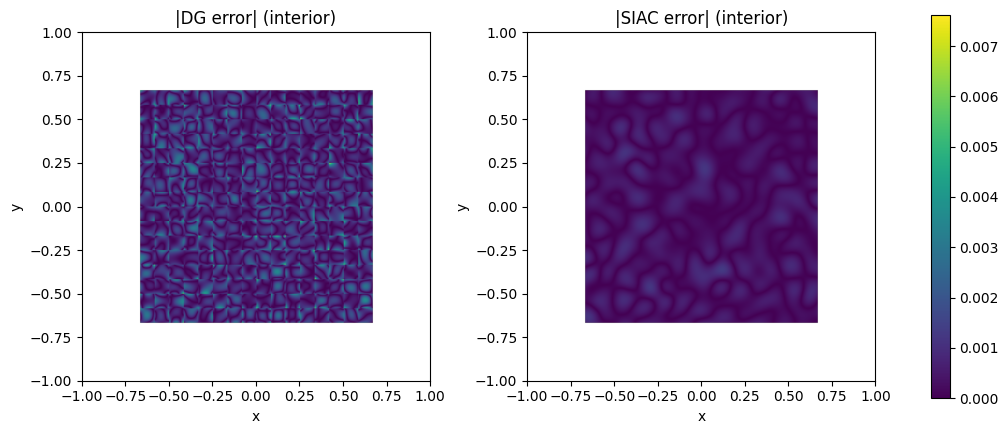

In [6]:

# --------------------------------------------------
# 7. Plots: exact, DG, SIAC
# --------------------------------------------------
# Visualize only the valid interior region while keeping full-size images:

dg_err_plot = np.full_like(U_exact, np.nan, dtype=float)
siac_err_plot = np.full_like(U_exact, np.nan, dtype=float)

sl = slice(trim, -trim)
dg_err_plot[sl, sl] = np.abs(err_dg)
siac_err_plot[sl, sl] = np.abs(err_siac)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axes[0].imshow(
    U_exact,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[0].set_title("Exact")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    U_dg,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[1].set_title("DG (L2 projection)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(
    U_siac,
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal"
)
axes[2].set_title("SIAC")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.show()

# --------------------------------------------------
# 8. Error plots
# --------------------------------------------------

rel_l2_err_siac = np.linalg.norm(err_siac) / np.linalg.norm(exact_trim)
rel_l2_err_dg = np.linalg.norm(err_dg) / np.linalg.norm(exact_trim)
ratio = rel_l2_err_siac / rel_l2_err_dg

use_shared_scale = (1e-2 <= ratio <= 1e2)

if use_shared_scale:
    vmin = 0.0
    vmax = max(np.max(np.abs(err_dg)),
               np.max(np.abs(err_siac)))
else:
    vmin = vmax = None

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

im3 = axes[0].imshow(
    np.abs(dg_err_plot),
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal",
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("|DG error| (interior)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im4 = axes[1].imshow(
    np.abs(siac_err_plot),
    extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
    origin="lower",
    aspect="equal",
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("|SIAC error| (interior)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Shared colorbar if same scale
if use_shared_scale:
    fig.colorbar(im3, ax=axes, location="right", shrink=0.9)
else:
    fig.colorbar(im3, ax=axes[0])
    fig.colorbar(im4, ax=axes[1])

plt.show()